In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../../wavelet/')
import wavelet_funcs as wf

In [32]:
import matlab.engine

In [33]:
eng = matlab.engine.start_matlab()

In [34]:
n_signals = 30
nt = 1024

x = np.random.randn(n_signals, nt)
dt = 0.5
t = np.arange(nt)*dt

In [52]:
ps = []
for xi in x:
    res = wf.matlab_cwt(eng, x, 1/dt) # GMW tbw=60
    ps.append((res.wt_amp).mean('t').data)

Text(0, 0.5, 'Time-averaged $|WT|$')

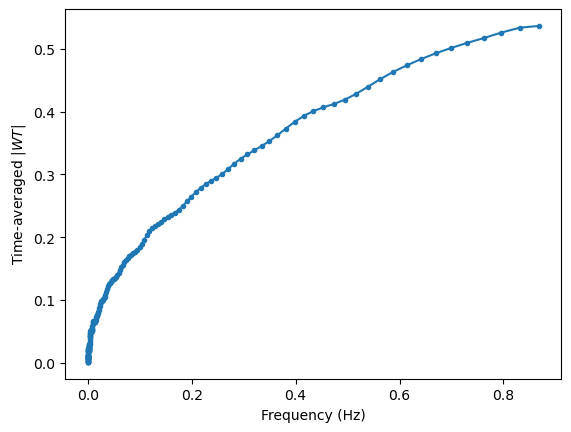

In [53]:
plt.plot(res.f, np.array(ps).mean(axis=0), marker='.')
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'Time-averaged $|WT|$')

Text(0, 0.5, 'Time-averaged $\\frac{|WT|}{\\sqrt{f}}$')

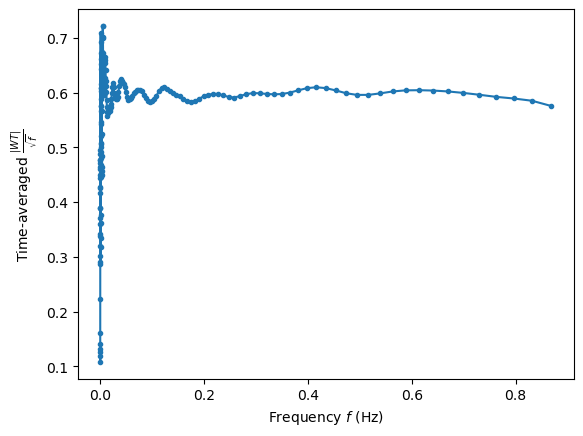

In [56]:
plt.plot(res.f, np.array(ps).mean(axis=0)/np.sqrt(res.f), marker='.')
# plt.xscale('log')
plt.xlabel(r'Frequency $f$ (Hz)')
plt.ylabel(r'Time-averaged $\frac{|WT|}{\sqrt{f}}$')